## Exploratory Data Analysis(EDA)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi agar lebih profesional
sns.set_theme(style="whitegrid")

# 1. Load Dataset
# Asumsikan dataset bernama 'student_depression.csv'
df = pd.read_csv('../Bengkod-Depresi.csv')

# Menampilkan 5 baris pertama
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


In [28]:
# Cek informasi umum dataset (tipe data dan non-null count)
print("Informasi Dataset:")
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 non-nu

In [29]:
# Cek persentase missing values di setiap kolom
print("\Jumlah Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

\Jumlah Missing Values:
Financial Stress                    45
Family History of Mental Illness    42
Depression                          42
dtype: int64


In [30]:
# Cek distribusi statistik untuk kolom numerik (Age, CGPA, Work/Study Hours, dll.)
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


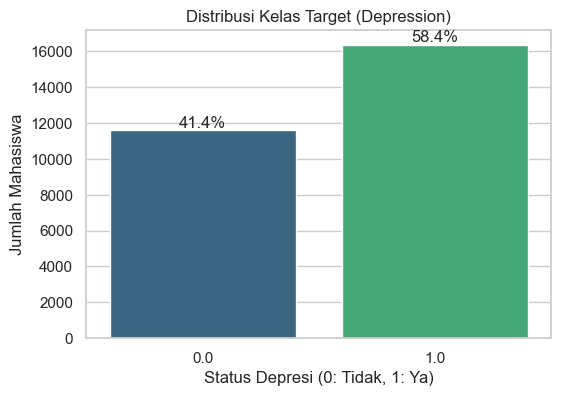

In [31]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Depression', palette='viridis')
plt.title('Distribusi Kelas Target (Depression)')
plt.xlabel('Status Depresi (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Mahasiswa')

# Menambahkan label persentase di atas bar
total = len(df['Depression'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

### Insight 1: Pengaruh Tekanan Akademik dan Beban Studi

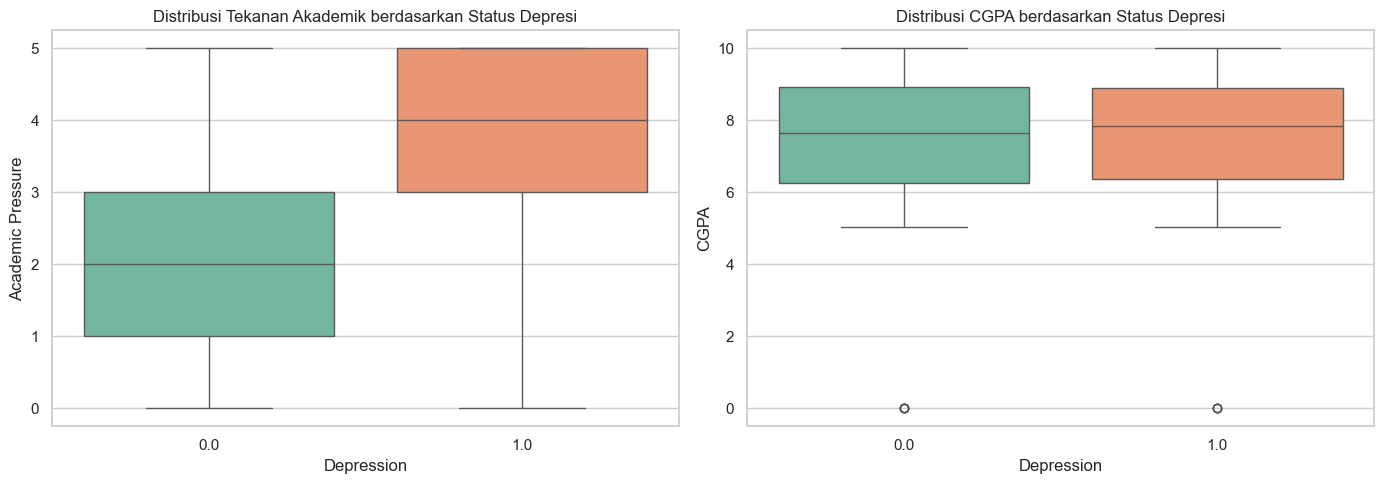

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Academic Pressure vs Depression
sns.boxplot(data=df, x='Depression', y='Academic Pressure', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Tekanan Akademik berdasarkan Status Depresi')

# Plot CGPA vs Depression
sns.boxplot(data=df, x='Depression', y='CGPA', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi CGPA berdasarkan Status Depresi')

plt.tight_layout()
plt.show()

### Insight 2: Faktor Kesehatan Mental Klinis dan Riwayat

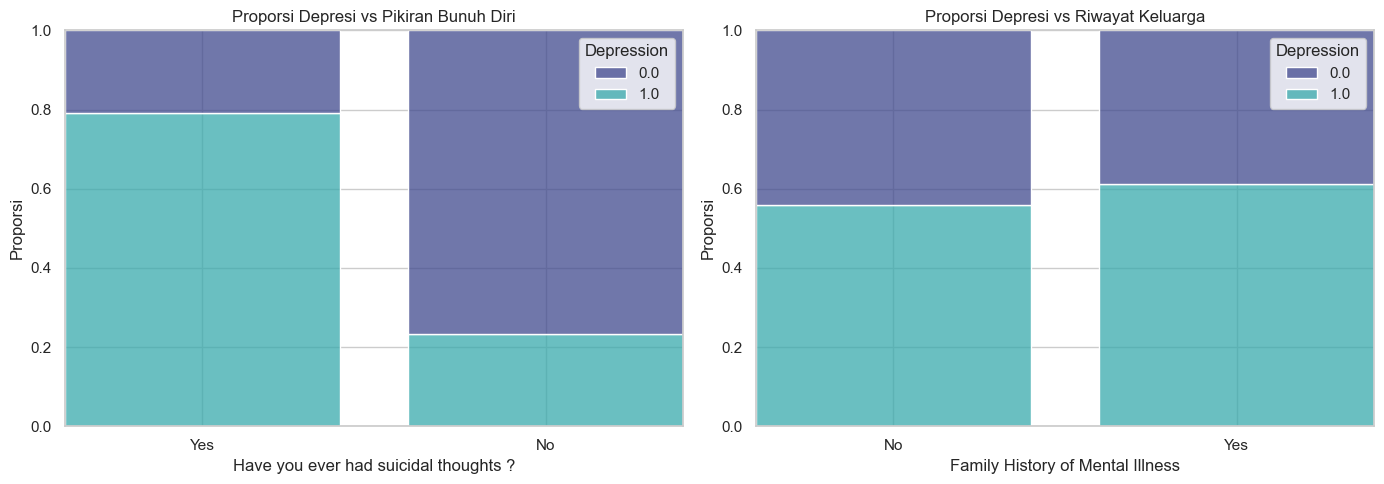

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rasio Depresi berdasarkan Pikiran Bunuh Diri
sns.histplot(data=df, x='Have you ever had suicidal thoughts ?', hue='Depression', multiple='fill', shrink=.8, palette='mako', ax=axes[0])
axes[0].set_title('Proporsi Depresi vs Pikiran Bunuh Diri')
axes[0].set_ylabel('Proporsi')

# Rasio Depresi berdasarkan Riwayat Keluarga
sns.histplot(data=df, x='Family History of Mental Illness', hue='Depression', multiple='fill', shrink=.8, palette='mako', ax=axes[1])
axes[1].set_title('Proporsi Depresi vs Riwayat Keluarga')
axes[1].set_ylabel('Proporsi')

plt.tight_layout()
plt.show()

### Insight 3: Dampak Pola Hidup (Durasi Tidur & Pola Makan)

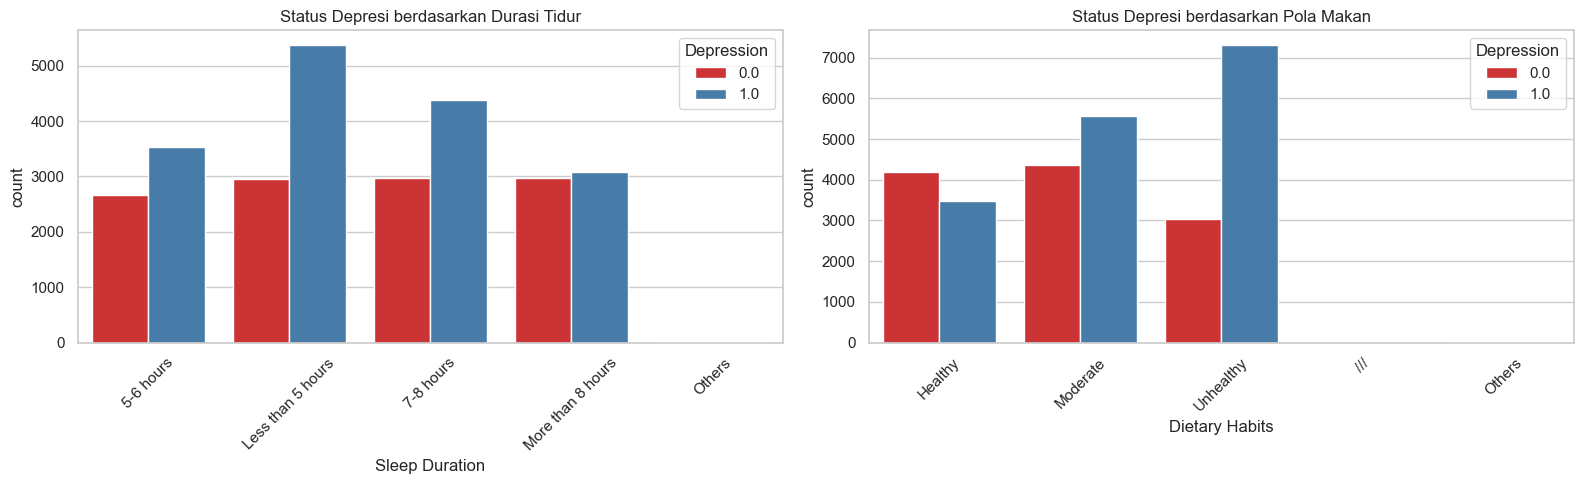

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rasio Depresi berdasarkan Durasi Tidur
sns.countplot(data=df, x='Sleep Duration', hue='Depression', palette='Set1', ax=axes[0])
axes[0].set_title('Status Depresi berdasarkan Durasi Tidur')
axes[0].tick_params(axis='x', rotation=45)

# Rasio Depresi berdasarkan Kebiasaan Makan
sns.countplot(data=df, x='Dietary Habits', hue='Depression', palette='Set1', ax=axes[1])
axes[1].set_title('Status Depresi berdasarkan Pola Makan')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Direct Modeling (Baseline)

Kita akan melatih 5 model *machine learning* secara langsung menggunakan data mentah. Tujuan utamanya adalah untuk menetapkan *baseline score* (skor dasar) yang akan menjadi parameter pembanding setelah kita melakukan *preprocessing* nanti.

**Alasan Pemilihan 5 Model:**
1. **Logistic Regression:** Model ini sangat baik untuk melihat apakah dataset memiliki hubungan linier yang kuat terhadap target `Depression`.
2. **Decision Tree Classifier:** Dipilih sebagai representasi model non-linier dasar yang mudah diinterpretasikan (melalui aturan *if-else*).
3. **Random Forest Classifier (Ensemble Bagging):** Model *ensemble* karena kemampuannya menangani interaksi fitur yang kompleks secara otomatis dan mencegah *overfitting* yang sering terjadi pada *Decision Tree* tunggal.
4. **XGBoost / Gradient Boosting (Ensemble Boosting):** Merupakan algoritma *State-of-the-Art* untuk data tabular. Dipilih karena performanya yang terkenal sangat tinggi dan mampu meminimalkan *bias* secara berurutan.
5. **K-Nearest Neighbors (KNN):** Dipilih sebagai representasi model berbasis jarak (*distance-based*). KNN sengaja dipilih pada tahap *Direct Modeling* karena biasanya akan memberikan performa yang buruk jika data belum di-*scaling*. Ini akan menjadi bukti yang sangat kuat mengapa tahap *preprocessing* (khususnya *scaling*) sangat krusial di tahap selanjutnya.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# --- PERSIAPAN DATA MENTAH MINIMALIS ---
# Drop ID karena tidak relevan
df_raw = df.drop(columns=['ID'], errors='ignore')

# Hapus missing values sementara HANYA untuk bisa menjalankan baseline
df_raw = df_raw.dropna()

# Pisahkan fitur (X) dan target (y)
X = df_raw.drop('Depression', axis=1)
y = df_raw['Depression']

# Lakukan One-Hot Encoding minimalis agar model tidak error karena data string
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}\n")

Dimensi X_train: (22370, 111)
Dimensi X_test: (5593, 111)



In [36]:
# --- INISIALISASI 5 MODEL ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [37]:
# --- TRAINING & EVALUASI BASELINE ---
baseline_results = []

print("=== HASIL EVALUASI DIRECT MODELING (BASELINE) ===")
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Simpan hasil untuk komparasi nanti
    baseline_results.append({
        "Model": name,
        "Accuracy (Baseline)": acc,
        "F1-Score (Baseline)": f1
    })

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 30)

=== HASIL EVALUASI DIRECT MODELING (BASELINE) ===
--- Logistic Regression ---
Accuracy : 0.8434
F1-Score : 0.8688
------------------------------
--- Decision Tree ---
Accuracy : 0.7769
F1-Score : 0.8105
------------------------------
--- Random Forest ---
Accuracy : 0.8412
F1-Score : 0.8671
------------------------------
--- Gradient Boosting ---
Accuracy : 0.8455
F1-Score : 0.8702
------------------------------
--- K-Nearest Neighbors ---
Accuracy : 0.5360
F1-Score : 0.6274
------------------------------


In [38]:
# Tampilkan hasil dalam bentuk DataFrame agar rapi
df_baseline = pd.DataFrame(baseline_results).sort_values(by="F1-Score (Baseline)", ascending=False)
display(df_baseline)

,Model,Accuracy (Baseline),F1-Score (Baseline)
3,Gradient Boosting,0.845521,0.870192
0,Logistic Regression,0.843376,0.868784
2,Random Forest,0.841230,0.867106
1,Decision Tree,0.776864,0.810507
4,K-Nearest Neighbors,0.536027,0.627423


## 3. Modeling Dengan Preprocessing

Berdasarkan *insight* yang didapatkan dari tahap Exploratory Data Analysis (EDA), data mentah kita memiliki berbagai tipe (numerik, kategorikal nominal, dan kategorikal ordinal) dengan skala yang berbeda-beda. Oleh karena itu, kita merancang strategi *preprocessing* sebagai berikut:

1. **Handling Missing Values:** Menggunakan `SimpleImputer` untuk mengisi nilai yang hilang. Kolom numerik diisi dengan nilai median (agar tahan terhadap *outlier*), sedangkan kolom kategorikal diisi dengan modus (nilai yang paling sering muncul).
2. **Numeric Scaling:** Fitur seperti `Age`, `CGPA`, nilai tekanan/kepuasan (0-5), dan jam kerja memiliki rentang yang berbeda. Kita menggunakan `StandardScaler` untuk menstandarisasi fitur numerik agar model berbasis jarak dan gradien dapat beroperasi secara optimal.
3. **Categorical Encoding (Nominal):** Fitur yang tidak memiliki tingkatan (seperti `Gender`, `City`, `Profession`, `Degree`) akan diubah menggunakan `OneHotEncoder`.
4. **Categorical Encoding (Ordinal/Biner):** Fitur yang memiliki hierarki atau bernilai biner (seperti `Sleep Duration`, `Dietary Habits`, pemikiran bunuh diri, riwayat keluarga) akan diubah menggunakan `OrdinalEncoder` agar model memahami urutan bobotnya.

Kita akan menggunakan `Pipeline` untuk merangkai semua proses ini secara sekuensial dan melatih kembali 5 model yang sama seperti pada tahap *baseline*.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# --- 1. DEFINISI KOLOM BERDASARKAN TIPE DATA ---
# Pastikan nama kolom sesuai persis dengan dataframe Anda
num_features = ['Age', 'CGPA', 'Work Pressure', 'Academic Pressure',
                'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

nom_features = ['Gender', 'City', 'Profession', 'Degree']

ord_features = ['Sleep Duration', 'Dietary Habits',
                'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

In [40]:
# --- 2. PEMBUATAN TRANSFORMER ---
# Preprocessing untuk data numerik: Imputasi dengan median -> Standard Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing untuk data kategorikal nominal: Imputasi modus -> One-Hot Encoding
nom_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessing untuk data kategorikal ordinal: Imputasi modus -> Ordinal Encoding
ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Menggabungkan semua transformer ke dalam ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('nom', nom_transformer, nom_features),
        ('ord', ord_transformer, ord_features)
    ])

In [41]:
# --- 3. PERSIAPAN DATA ULANG ---
# Kita gunakan kembali data awal (df) tanpa menghapus missing values manual
# ID didrop karena tidak ada nilai prediktif
X_clean = df.drop(columns=['ID', 'Depression'], errors='ignore')
y_clean = df['Depression']

# Handle missing values in target variable 'Depression' before splitting
# This ensures that stratify=y_clean works without errors
valid_indices = y_clean.dropna().index
X_clean = X_clean.loc[valid_indices]
y_clean = y_clean.loc[valid_indices]

# Split data (pastikan random_state sama dengan tahap baseline untuk perbandingan yang *apple-to-apple*)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

In [42]:
# --- 4. TRAINING & EVALUASI DENGAN PIPELINE ---
preprocessed_results = []

print("=== HASIL EVALUASI MODELING DENGAN PREPROCESSING ===")
for name, model in models.items():
    # Bungkus preprocessor dan model ke dalam satu Pipeline
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Training (Pipeline akan otomatis melakukan fit_transform pada preprocessor, lalu fit pada model)
    clf_pipeline.fit(X_train_clean, y_train_clean)

    # Prediksi (Pipeline otomatis melakukan transform pada test set)
    y_pred_clean = clf_pipeline.predict(X_test_clean)

    # Evaluasi
    acc_clean = accuracy_score(y_test_clean, y_pred_clean)
    f1_clean = f1_score(y_test_clean, y_pred_clean)

    # Simpan hasil
    preprocessed_results.append({
        "Model": name,
        "Accuracy (Preprocessed)": acc_clean,
        "F1-Score (Preprocessed)": f1_clean
    })

    print(f"--- {name} ---")
    print(f"Accuracy : {acc_clean:.4f}")
    print(f"F1-Score : {f1_clean:.4f}")
    print("-" * 30)

=== HASIL EVALUASI MODELING DENGAN PREPROCESSING ===
--- Logistic Regression ---
Accuracy : 0.8450
F1-Score : 0.8699
------------------------------
--- Decision Tree ---
Accuracy : 0.7767
F1-Score : 0.8083
------------------------------
--- Random Forest ---
Accuracy : 0.8434
F1-Score : 0.8691
------------------------------
--- Gradient Boosting ---
Accuracy : 0.8493
F1-Score : 0.8734
------------------------------
--- K-Nearest Neighbors ---
Accuracy : 0.8125
F1-Score : 0.8456
------------------------------


In [43]:
# --- 5. KOMPARASI BASELINE VS PREPROCESSED ---
df_preprocessed = pd.DataFrame(preprocessed_results)

# Menggabungkan dataframe hasil baseline dan hasil preprocessing untuk melihat peningkatannya
df_comparison = pd.merge(df_baseline, df_preprocessed, on="Model")
df_comparison['F1 Improvement'] = df_comparison['F1-Score (Preprocessed)'] - df_comparison['F1-Score (Baseline)']

print("\n=== PERBANDINGAN PERFORMA: BASELINE VS PREPROCESSING ===")
display(df_comparison.sort_values(by="F1-Score (Preprocessed)", ascending=False))


=== PERBANDINGAN PERFORMA: BASELINE VS PREPROCESSING ===


,Model,Accuracy (Baseline),F1-Score (Baseline),Accuracy (Preprocessed),F1-Score (Preprocessed),F1 Improvement
0,Gradient Boosting,0.845521,0.870192,0.849303,0.873442,0.003250
1,Logistic Regression,0.843376,0.868784,0.845013,0.869878,0.001095
2,Random Forest,0.841230,0.867106,0.843404,0.869137,0.002031
4,K-Nearest Neighbors,0.536027,0.627423,0.812478,0.845622,0.218199
3,Decision Tree,0.776864,0.810507,0.776725,0.808347,-0.002160


## 4. Feature Selection

Untuk menyeleksi fitur yang paling relevan terhadap `Depression`, kita akan menggunakan metode **Tree-based Feature Selection** memanfaatkan `RandomForestClassifier`. Metode ini dipilih karena:
1. Mampu menangkap hubungan non-linier antara fitur dan variabel target.
2. Sangat efektif untuk mengevaluasi fitur hasil *One-Hot Encoding* yang jumlahnya banyak (seperti pada kolom City atau Profession).

**Langkah yang dilakukan:**
1. Mengambil nilai *Feature Importances* dari model Random Forest yang telah dilatih pada tahap sebelumnya untuk memvisualisasikan fitur mana yang paling berpengaruh.
2. Memasukkan modul `SelectFromModel` ke dalam `Pipeline` kita. Modul ini secara otomatis akan membuang fitur-fitur yang tingkat kepentingannya (*importance*) berada di bawah nilai rata-rata (atau *threshold* yang ditentukan), sehingga model akhir dilatih menggunakan subset fitur terbaik.

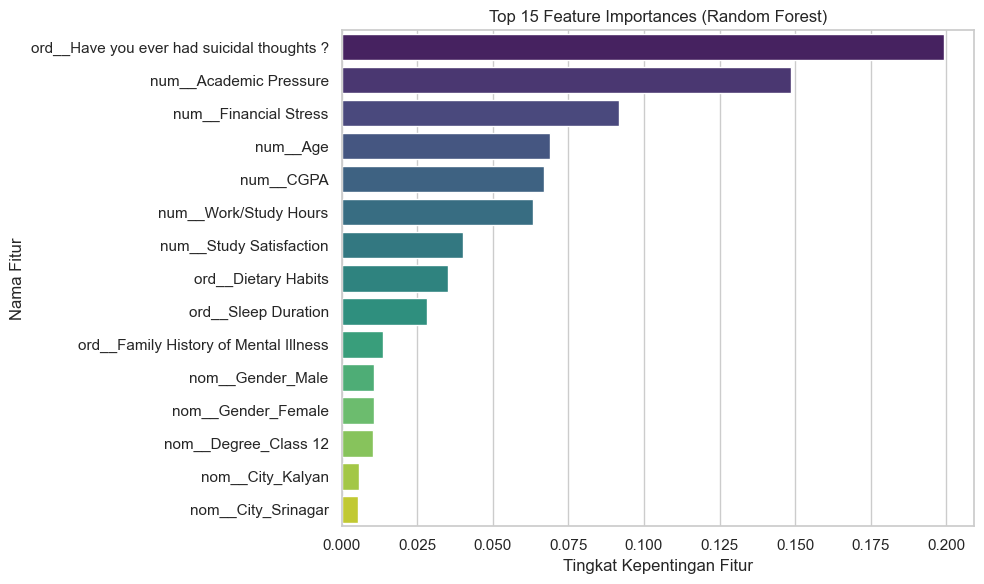

In [44]:
from sklearn.feature_selection import SelectFromModel
import numpy as np

# --- 1. VISUALISASI FEATURE IMPORTANCES ---
# Kita ambil model Random Forest dari hasil preprocessed_results di tahap 3
# Asumsikan kita membuat ulang pipeline RF untuk mengekstrak feature names
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train_clean, y_train_clean)

# Mengekstrak nama fitur setelah preprocessing (berguna untuk melihat hasil One-Hot Encoding)
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Mengekstrak nilai importances dari model Random Forest
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Membuat DataFrame untuk visualisasi
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot 15 Fitur Terpenting
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

In [45]:
# --- 2. RETRAINING MODEL DENGAN FEATURE SELECTION ---
print("=== HASIL EVALUASI MODELING DENGAN FEATURE SELECTION ===")

feature_selection_results = []
selector = SelectFromModel(RandomForestClassifier(random_state=42, n_jobs=-1))

for name, model in models.items():
    # Pipeline baru: Preprocessor -> Feature Selection -> Classifier
    fs_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', selector), # Memilih fitur secara otomatis
        ('classifier', model)
    ])

    # Training
    fs_pipeline.fit(X_train_clean, y_train_clean)

    # Prediksi
    y_pred_fs = fs_pipeline.predict(X_test_clean)

    # Evaluasi
    acc_fs = accuracy_score(y_test_clean, y_pred_fs)
    f1_fs = f1_score(y_test_clean, y_pred_fs)

    feature_selection_results.append({
        "Model": name,
        "Accuracy (FS)": acc_fs,
        "F1-Score (FS)": f1_fs
    })

    print(f"--- {name} ---")
    print(f"Accuracy : {acc_fs:.4f}")
    print(f"F1-Score : {f1_fs:.4f}")
    print("-" * 30)

# Menampilkan perbandingan dimensi fitur sebelum dan sesudah seleksi
X_train_transformed = preprocessor.transform(X_train_clean)
X_train_selected = selector.fit_transform(X_train_transformed, y_train_clean)
print(f"\nJumlah fitur sebelum seleksi: {X_train_transformed.shape[1]}")
print(f"Jumlah fitur setelah seleksi : {X_train_selected.shape[1]}")

=== HASIL EVALUASI MODELING DENGAN FEATURE SELECTION ===
--- Logistic Regression ---
Accuracy : 0.8455
F1-Score : 0.8702
------------------------------
--- Decision Tree ---
Accuracy : 0.7694
F1-Score : 0.8023
------------------------------
--- Random Forest ---
Accuracy : 0.8379
F1-Score : 0.8634
------------------------------
--- Gradient Boosting ---
Accuracy : 0.8489
F1-Score : 0.8731
------------------------------
--- K-Nearest Neighbors ---
Accuracy : 0.8177
F1-Score : 0.8488
------------------------------

Jumlah fitur sebelum seleksi: 102
Jumlah fitur setelah seleksi : 13


In [46]:
# --- 3. KOMPARASI FINAL ---
df_fs = pd.DataFrame(feature_selection_results)
df_final_comparison = pd.merge(df_comparison, df_fs, on="Model")
display(df_final_comparison[['Model', 'F1-Score (Baseline)', 'F1-Score (Preprocessed)', 'F1-Score (FS)']].sort_values(by='F1-Score (FS)', ascending=False))

,Model,F1-Score (Baseline),F1-Score (Preprocessed),F1-Score (FS)
0,Gradient Boosting,0.870192,0.873442,0.873142
1,Logistic Regression,0.868784,0.869878,0.870231
2,Random Forest,0.867106,0.869137,0.863424
4,K-Nearest Neighbors,0.627423,0.845622,0.848844
3,Decision Tree,0.810507,0.808347,0.802269


## 5. Hyperparameter Tuning

Berdasarkan hasil komparasi pada tahap sebelumnya, **Gradient Boosting** terbukti menjadi model dengan performa terbaik. Oleh karena itu, kita akan mengoptimalkan *hyperparameter* dari model ini menggunakan `RandomizedSearchCV`.

**Parameter Gradient Boosting yang akan di-tuning:**
* `n_estimators`: Jumlah tahapan *boosting* yang akan dilakukan (jumlah pohon).
* `learning_rate`: Mengontrol seberapa besar kontribusi setiap pohon terhadap prediksi akhir.
* `max_depth`: Kedalaman maksimum dari masing-masing pohon (mencegah *overfitting*).
* `min_samples_split` & `min_samples_leaf`: Syarat minimum sampel untuk memecah *node* dan membuat daun (*leaf*).

Kita akan menggunakan metrik evaluasi **F1-Score** sebagai target utama, mengingat ini adalah kasus klasifikasi kondisi psikologis di mana meminimalkan *False Negatives* sangatlah penting. Model terbaik hasil *tuning* akan langsung disimpan menjadi file `.pkl` untuk digunakan pada aplikasi Streamlit.

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import joblib
import os

print("=== MEMULAI HYPERPARAMETER TUNING (GRADIENT BOOSTING) ===")

# --- 1. DEFINISI PARAMETER GRID ---
param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Membuat Pipeline utuh: Preprocessor -> Classifier (Gradient Boosting)
# Pastikan 'preprocessor' dari Tahap 3 sudah di-run sebelumnya
pipeline_to_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

=== MEMULAI HYPERPARAMETER TUNING (GRADIENT BOOSTING) ===


In [48]:
# --- 2. SETUP RANDOMIZED SEARCH ---
random_search = RandomizedSearchCV(
    estimator=pipeline_to_tune,
    param_distributions=param_dist,
    n_iter=20,          # Mencoba 20 kombinasi acak
    scoring='f1',       # Kita ganti target scoring ke F1-Score!
    cv=5,               # 5-fold Cross Validation
    n_jobs=-1,          # Gunakan semua core CPU agar cepat
    random_state=42,
    verbose=2
)

In [49]:
# --- 3. EKSEKUSI TUNING ---
print("Mencari kombinasi hyperparameter terbaik... (Tunggu sebentar ya)")
random_search.fit(X_train_clean, y_train_clean)

# Mengekstrak model terbaik
best_gb_model = random_search.best_estimator_

print("\n=== HASIL HYPERPARAMETER TUNING ===")
print(f"Kombinasi Parameter Terbaik: \n{random_search.best_params_}")
print(f"Skor F1 (Cross-Validation): {random_search.best_score_:.4f}")

Mencari kombinasi hyperparameter terbaik... (Tunggu sebentar ya)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== HASIL HYPERPARAMETER TUNING ===
Kombinasi Parameter Terbaik: 
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}
Skor F1 (Cross-Validation): 0.8716


In [50]:
# --- 4. EVALUASI MODEL TERBAIK DI TEST SET ---
y_pred_tuned = best_gb_model.predict(X_test_clean)
acc_tuned = accuracy_score(y_test_clean, y_pred_tuned)
f1_tuned = f1_score(y_test_clean, y_pred_tuned)

print("\n--- Performa Model Terbaik pada Test Set ---")
print(f"Accuracy : {acc_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print("\nClassification Report:\n", classification_report(y_test_clean, y_pred_tuned))


--- Performa Model Terbaik pada Test Set ---
Accuracy : 0.8484
F1-Score : 0.8725

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.80      0.81      2320
         1.0       0.86      0.89      0.87      3274

    accuracy                           0.85      5594
   macro avg       0.85      0.84      0.84      5594
weighted avg       0.85      0.85      0.85      5594



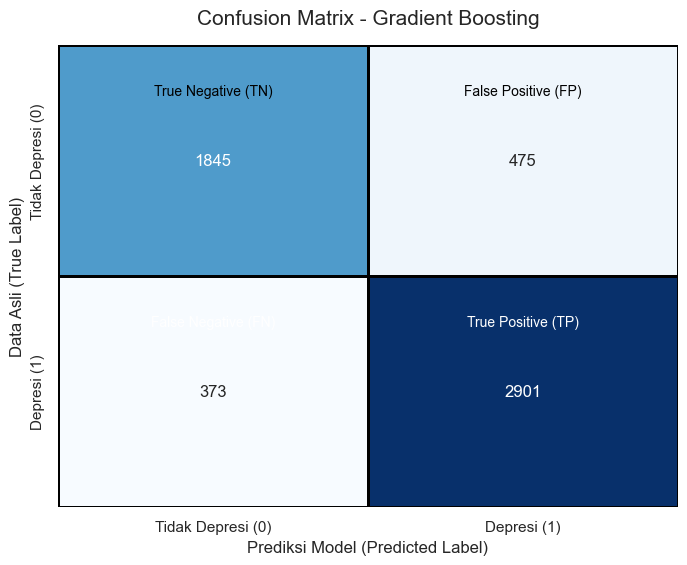

In [ ]:
from sklearn.metrics import confusion_matrix

# Menghitung confusion matrix menggunakan label asli test set dan hasil prediksi model terbaik
cm = confusion_matrix(y_test_clean, y_pred_tuned)

# Memvisualisasikan Confusion Matrix menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            linewidths=1, linecolor='black',
            xticklabels=['Tidak Depresi (0)', 'Depresi (1)'],
            yticklabels=['Tidak Depresi (0)', 'Depresi (1)'])

plt.title('Confusion Matrix - Gradient Boosting', fontsize=15, pad=15)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
plt.ylabel('Data Asli (True Label)', fontsize=12)

# Menambahkan teks anotasi TN, FP, FN, TP untuk mempermudah pembacaan
plt.text(0.5, 0.2, 'True Negative (TN)', ha='center', va='center', color='black', fontsize=10)
plt.text(1.5, 0.2, 'False Positive (FP)', ha='center', va='center', color='black', fontsize=10)
plt.text(0.5, 1.2, 'False Negative (FN)', ha='center', va='center', color='white', fontsize=10)
plt.text(1.5, 1.2, 'True Positive (TP)', ha='center', va='center', color='white', fontsize=10)

plt.show()

In [51]:
# --- 5. EXPORT MODEL UNTUK DEPLOYMENT ---
os.makedirs('model', exist_ok=True)
# Kita beri nama spesifik agar tidak tertukar
model_filename = 'model/student_depression_gb_model.pkl' 
joblib.dump(best_gb_model, model_filename)

print(f"\n[SUKSES] Model final berhasil disimpan ke: {model_filename}")


[SUKSES] Model final berhasil disimpan ke: model/student_depression_gb_model.pkl
